In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lc_reconstruction_analysis.utils as utils
import lc_reconstruction_analysis.dendritic as dendritic
import lc_reconstruction_analysis.clustering as clustering
import lc_reconstruction_analysis.axon as axon
import lc_reconstruction_analysis.correlation as correlation
%matplotlib inline

#### other comparisons to make
evaluate null models.
hypothesis #1: there are two distinct projection groups
null model: there is one group.
method: permutation test, between neurons shuffle axonal length in brain regions. compute explained variance of k=2 means

hypothesis #2: there is a single population with continuous spatial variability.
null model: there is not a monotonic relationship between projections and space.
method: regression (for different models, linear, polynomial, sigmoid...) for soma position vs projections, look at slope. compare to shuffled soma positions.

In [2]:
# Define path to data
DATA_DIR = Path("/data/")
# Load data frame of cells, and networkx graphs
dataDF, graphs = utils.load_cells(DATA_DIR)

Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N064-68221-JN.json
Missing structure axon for /data/685221_12_5_24/Complete_annotated/N064-685221-JN.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N025-685221-PG.json
Missing structure dendrite for /data/648434_12_5_24/Complete_annotated/N024-648434-SS.json
Error finding structures for: N025-685221-PG, dropping from dataframe
Error finding structures for: N064-68221-JN, dropping from dataframe
Error finding structures for: N064-685221-JN, dropping from dataframe
Error finding structures for: N051-685221 -YP, dropping from dataframe
Error finding structures for: N024-648434-SS, dropping from dataframe


In [3]:
# Exclude any neurons that need to be excluded
excludeList = [ # Look like MY cells mistakenly included in LC batch
    "N039-685222-AK",
    "N040-685222-VM",
    "N066-685221-JN",
    "N068-685221-HD",
    "N067-685221-HS"
]

dataDF = dataDF.drop(dataDF[dataDF["Graph"].isin(excludeList)].index)

In [4]:
# Load data
df = clustering.build_length_df(dataDF, graphs, DATA_DIR, normalize_df=False)
df = df.drop(list(set(df.index) - set(dataDF["Graph"]))) # Drop graphs not included in dataDF
# Normalize length within each neuron
dfNorm = df.copy()
dfNorm = dfNorm.divide(dfNorm.sum(axis=1),axis=0)
# Merge dataframes
sorted_columns = ["OLF","Isocortex","HPF","CTXsp","CNU","TH","HY","MB","CB","P","MY","Other"]
plotDF = dataDF.copy().merge(dfNorm[sorted_columns], left_on="Graph", right_index = True)

In [5]:
# Add total length
plotDF = plotDF.merge(pd.Series(df.sum(axis=1) / 1e4 , name = "Total Length (cm)"), left_on="Graph",right_index = True) # convert from microns to centimeters
plotDF["Norm Length"] = plotDF["Total Length (cm)"] / plotDF["Total Length (cm)"].max()

# Compute total axonal branches
axon_branch_dict = {}
for name in plotDF["Graph"]:
    graph = graphs[name]
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    axon_branch_dict[name] = len(axon_branch_nodes)

# Add axonal branches to dataframe
plotDF = plotDF.merge(pd.Series(axon_branch_dict, name = "Axon Branches"), left_on = "Graph", right_index = True)
plotDF["Norm Branches"] = plotDF["Axon Branches"] / plotDF["Axon Branches"].max()

In [6]:
plotDF.head(3)

,Graph,ID,Sample,Annotator,Genotype,somaAP,somaDV,somaML,somaOnRight,OLF,...,HY,MB,CB,P,MY,Other,Total Length (cm),Norm Length,Axon Branches,Norm Branches
6,N001-685221-PG,N001,685221,PG,Dbh-Cre-KI/wt,10201.676000,4571.162500,4612.849100,False,0.000000,...,0.020860,0.255037,0.000000,0.071944,0.338564,0.173288,14.318932,0.197319,103,0.066796
66,N001-685222-SA,N001,685222,SA,Dbh-Cre-KI/wt,10345.217200,4145.213600,4709.684200,True,0.047268,...,0.028757,0.040161,0.006982,0.004348,0.000000,0.009400,72.567420,1.000000,982,0.636835
131,N001-721332-HP,N001,721332,HP,Dbh-Cre-KI/wt,10254.754578,4470.771631,4613.168027,False,0.000000,...,0.000000,0.006419,0.000000,0.025053,0.177489,0.779280,21.465195,0.295797,283,0.183528


## Compute correlation between each neuron

In [7]:
from itertools import combinations

In [8]:
# Establish an absolute sorting based on DV position
unnormalized_sorted_columns = [f"unnorm_{col}" for col in sorted_columns]
useDF = plotDF.copy().merge(df[sorted_columns].rename(columns = {col: new_col for col, new_col in zip(sorted_columns,unnormalized_sorted_columns)}), left_on="Graph", right_index=True)
useDF = useDF.sort_values("somaDV",ascending=True)
useDF = useDF.reset_index(drop=True)
useDF.head(3)

,Graph,ID,Sample,Annotator,Genotype,somaAP,somaDV,somaML,somaOnRight,OLF,...,unnorm_HPF,unnorm_CTXsp,unnorm_CNU,unnorm_TH,unnorm_HY,unnorm_MB,unnorm_CB,unnorm_P,unnorm_MY,unnorm_Other
0,N019-685222-HS,N019,685222,HS,Dbh-Cre-KI/wt,10097.9499,3763.3747,5072.7667,False,0.056417,...,317874.071060,19623.830359,19723.240650,40396.054487,16056.793350,34720.494113,79.572309,6462.342879,16925.520114,20122.638309
1,N021-648434-PG,N021,648434,PG,Dbh-Cre-KI/wt,9981.7118,3798.5471,4966.5825,False,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3094.301371,13978.026433,998.329783,652.702648,0.000000
2,N009-685221-VM,N009,685221,VM,Dbh-Cre-KI/wt,10130.3109,4011.5415,4777.1360,True,0.054157,...,7100.040139,7344.768655,14283.974691,18315.167565,14751.644214,28838.919804,0.000000,10811.641962,19373.423933,2905.988801


In [116]:
useDF.loc[[0,6],["Graph"] + sorted_columns].T

,0,6
Graph,N019-685222-HS,N049-685221-SP
OLF,0.056417,0.062251
Isocortex,0.126479,0.191601
HPF,0.481565,0.157212
CTXsp,0.029729,0.007751
CNU,0.02988,0.17073
TH,0.061198,0.031149
HY,0.024325,0.056605
MB,0.0526,0.0726
CB,0.000121,0.050158


In [86]:
useDF.loc[[0,6],sorted_columns].T.corr()

,0,6
0,1.000000,0.534646
6,0.534646,1.000000


In [9]:
n = len(useDF)
nCombinations = (n * (n - 1)) // 2
print(f"{nCombinations} combinations for {n} neurons.")

5778 combinations for 108 neurons.


In [10]:
# Initialize output
data = np.zeros((nCombinations,10), dtype=np.float64)
# Loop through every pair of neurons
for indx, (i,j) in enumerate(combinations(useDF.index,2)):
    # Compute relevant metrics
    distDV = np.abs(useDF.loc[i,"somaDV"] - useDF.loc[j,"somaDV"])
    dist3D = np.linalg.norm(useDF.loc[i,["somaAP","somaDV","somaML"]].values - useDF.loc[j,["somaAP","somaDV","somaML"]].values)
    unnormPearson = useDF.loc[[i,j],unnormalized_sorted_columns].T.corr(method="pearson").iloc[0,1]
    unnormSpearman = useDF.loc[[i,j],unnormalized_sorted_columns].T.corr(method="spearman").iloc[0,1]
    corrPearson = useDF.loc[[i,j],sorted_columns].T.corr(method="pearson").iloc[0,1]
    corrSpearman = useDF.loc[[i,j],sorted_columns].T.corr(method="spearman").iloc[0,1]
    manhattanNorm = np.abs(useDF.loc[i,sorted_columns] - useDF.loc[j,sorted_columns]).sum()
    euclideanNorm = (((useDF.loc[i,sorted_columns]**.5) - (useDF.loc[j,sorted_columns]**.5)) ** 2).sum() ** .5
    data[indx] = [i, j, distDV, dist3D, unnormPearson, unnormSpearman, corrPearson, corrSpearman, manhattanNorm, euclideanNorm]

corrDF = pd.DataFrame(data,columns = ["i","j","distDV","dist3D","unnormPearson","unnormSpearman","corrPearson","corrSpearman","manhattanNorm", "euclideanNorm"])
corrDF[["i","j"]] = corrDF[["i","j"]].astype(int)

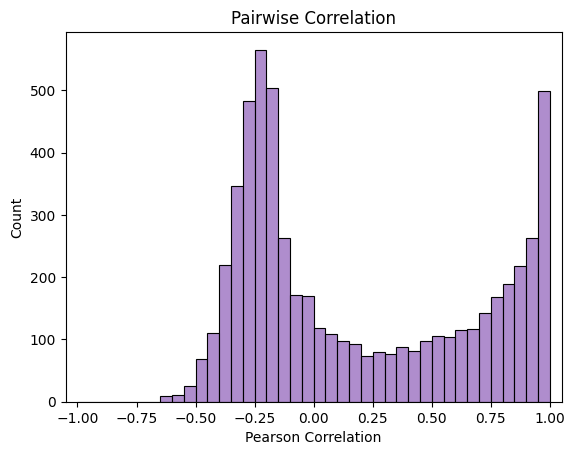

In [88]:
sns.histplot(corrDF["corrPearson"],bins = np.linspace(-1,1,41), color = "tab:purple")
plt.xlim([-1.05, 1.05])
# plt.ylim([0,575])
plt.xlabel("Pearson Correlation")
plt.title("Pairwise Correlation");
plt.savefig("../results/lc coarse projection pairwise pearson.png",dpi=300, bbox_inches='tight')

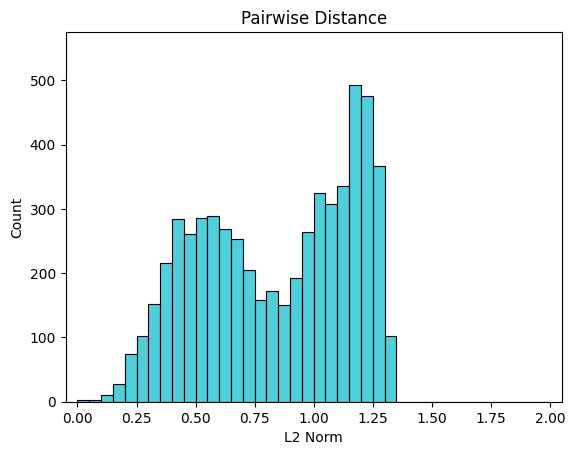

In [95]:
sns.histplot(corrDF["euclideanNorm"],bins = np.linspace(0,2,41), color = "tab:cyan")
plt.xlim([-0.05, 2.05])
plt.ylim([0,575])
plt.xlabel("L2 Norm")
plt.title("Pairwise Distance");
plt.savefig("../results/lc coarse projection pairwise L2 norm.png",dpi=300, bbox_inches='tight')

<Axes: >

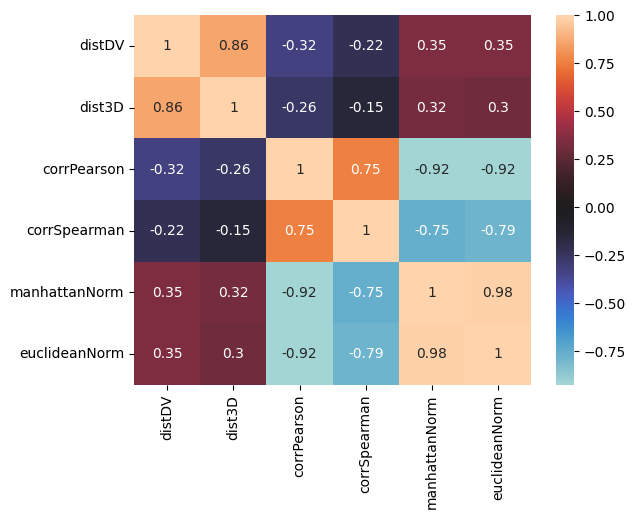

In [153]:
sns.heatmap(corrDF.loc[:,['distDV', 'dist3D','corrPearson', 'corrSpearman', 'manhattanNorm', 'euclideanNorm']].corr(), center = 0,annot = True)

In [156]:
shuffleCorrDF = corrDF.copy()
shuffleCorrDF["distDV"] = np.random.permutation(corrDF["distDV"].values)

<Axes: >

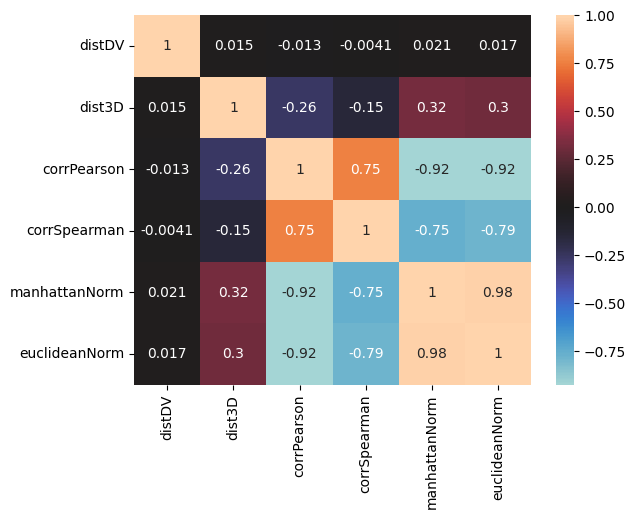

In [157]:
sns.heatmap(shuffleCorrDF.loc[:,['distDV', 'dist3D','corrPearson', 'corrSpearman', 'manhattanNorm', 'euclideanNorm']].corr(), center = 0,annot = True)

In [20]:
from scipy.stats import linregress
from sklearn.cluster import KMeans

In [177]:
X = useDF[sorted_columns].values
kmeans = KMeans(n_clusters=2, random_state=0).fit(X)
labels = kmeans.labels_

# plt.scatter(df['x'], df['y'], c=labels)
# plt.xlabel('x')
# plt.ylabel('y')
# plt.title('KMeans Clustering (k=2)')
# plt.show()

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


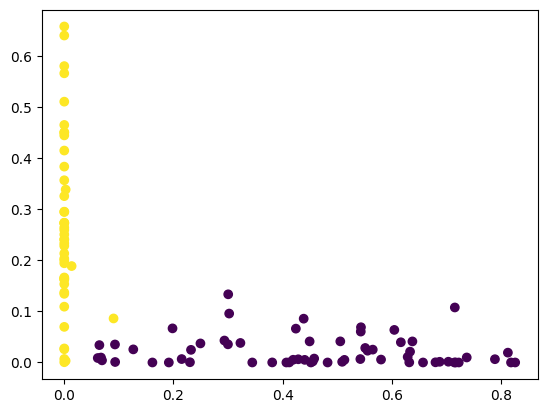

In [183]:
plt.scatter(useDF["Isocortex"],useDF["MY"],c = labels)

In [185]:
!pip install statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 108.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 kB 62.9 MB/s eta 0:00:00


In [22]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [187]:
corrDF[

,i,j,distDV,dist3D,unnormPearson,unnormSpearman,corrPearson,corrSpearman,manhattanNorm,euclideanNorm
0,0,1,35.1724,161.317941,-0.216800,-0.561662,-0.216800,-0.561662,1.496121,1.184986
1,0,2,248.1668,387.339006,0.103035,0.398601,0.103035,0.398601,1.061817,0.730127
2,0,3,289.3177,354.435902,-0.172563,-0.203863,-0.172563,-0.203863,1.624293,1.120089
3,0,4,323.8388,457.581447,0.511116,0.895105,0.511116,0.895105,0.760029,0.455351
4,0,5,326.6490,551.523537,0.122253,0.335664,0.122253,0.335664,1.074508,0.688170
...,...,...,...,...,...,...,...,...,...,...
5773,104,106,148.2661,238.460554,0.813234,0.670792,0.813234,0.670792,0.538429,0.525100
5774,104,107,834.7755,958.311970,0.745851,0.764537,0.745851,0.764537,0.578814,0.536004
5775,105,106,67.5362,213.846558,0.787882,0.918598,0.787882,0.918598,0.514569,0.420461
5776,105,107,754.0456,877.607736,0.660870,0.736961,0.660870,0.736961,0.746048,0.577861


In [ ]:
model1 = ols('y ~ x', data=df).fit()

In [174]:
x = corrDF["distDV"]
y = corrDF["corrSpearman"]
n_perm = 1000

actual_slope, _, _, actual_p, _ = linregress(x, y)
count = 0
for _ in range(n_perm):
    y_perm = np.random.permutation(y)
    slope_perm, _, _, _, _ = linregress(x, y_perm)
    if abs(slope_perm) >= abs(actual_slope):
        count += 1
count / n_perm

0.0

<Axes: xlabel='corrPearson', ylabel='Density'>

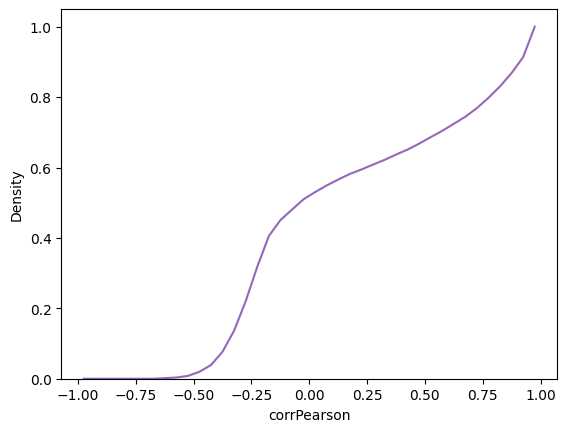

In [141]:
sns.histplot(corrDF["corrPearson"], bins = np.linspace(-1,1,41), color = "tab:purple", cumulative=True, stat = 'density', element = 'poly', fill = False)
# plt.xlim([-0.05, 2.05])
# plt.ylim([0,575])
# plt.title("Pairwise L2 Norm");
# plt.savefig("../results/lc coarse projection pairwise L2 norm.png",dpi=300, bbox_inches='tight')

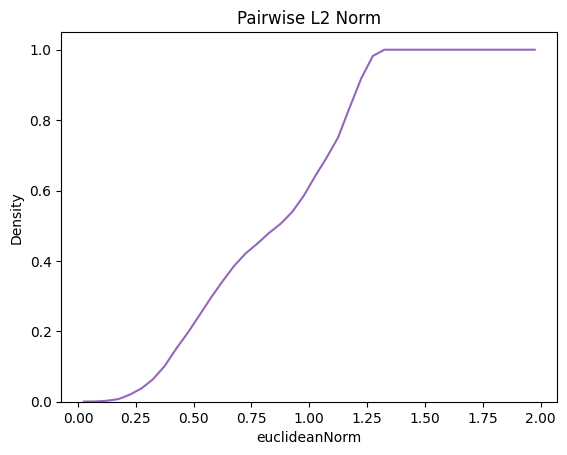

In [138]:
sns.histplot(corrDF["euclideanNorm"], bins = np.linspace(0,2,41), color = "tab:purple", cumulative=True, stat = 'density', element = 'poly', fill = False)
# plt.xlim([-0.05, 2.05])
# plt.ylim([0,575])
plt.title("Pairwise L2 Norm");
# plt.savefig("../results/lc coarse projection pairwise L2 norm.png",dpi=300, bbox_inches='tight')

<Axes: xlabel='distDV', ylabel='euclideanNorm'>

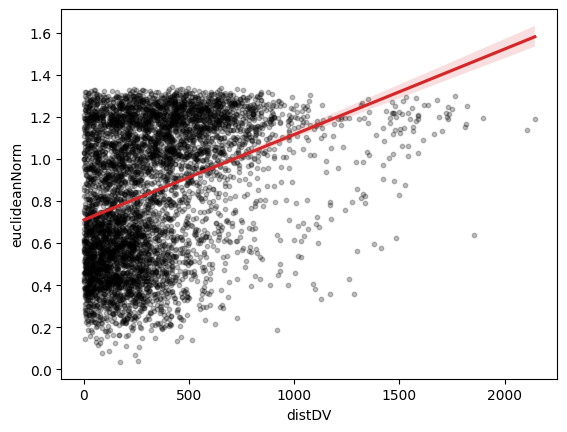

In [123]:
sns.regplot(corrDF,x = "distDV",y = "euclideanNorm", color = 'k', scatter_kws={'s' : 10, 'alpha': 0.25}, line_kws = {"color":'tab:red'})

In [27]:
from scipy.stats import skew, kurtosis

def bimodality_coefficient(data):
    g = skew(data)
    k = kurtosis(data, fisher=False)  # Use Pearson’s definition (normal = 3)
    return (g**2 + 1) / k if k != 0 else np.nan

In [13]:
bimodality_coefficient(corrDF["euclideanNorm"])

0.612066141550104

In [26]:
import time

In [318]:
bcShuffled

array([0.53876692, 0.50992743, 0.50377062, 0.52571213, 0.49948663])

In [324]:
# expect to take ~2 hrs with one thousand iterations

In [ ]:
shuffleDF = useDF.copy()

In [18]:
np.random.seed(seed = 33)
nIterations = 5
bcPearsonShuffled = np.zeros(nIterations)
bcSpearmanShuffled = np.zeros(nIterations)
bcManhattanShuffled = np.zeros(nIterations)
bcEuclidShuffled = np.zeros(nIterations)
start = time.time()
for k in range(nIterations):
    shuffleDF = useDF.copy()
    for col in unnormalized_sorted_columns:
        shuffleDF[col] = np.random.permutation(useDF[col].values)
    shuffleDF[sorted_columns] = shuffleDF[unnormalized_sorted_columns].divide(shuffleDF[unnormalized_sorted_columns].sum(axis=1),axis=0)
    shufflePearson = np.zeros(nCombinations,dtype=np.float64)
    shuffleSpearman = np.zeros(nCombinations,dtype=np.float64)
    shuffleManhattan = np.zeros(nCombinations,dtype=np.float64)
    shuffleEuclidNorm = np.zeros(nCombinations,dtype=np.float64)
    for indx, (i,j) in enumerate(combinations(useDF.index,2)):
        # Compute relevant metrics
        shufflePearson = useDF.loc[[i,j],sorted_columns].T.corr(method="pearson").iloc[0,1]
        shuffleSpearman = useDF.loc[[i,j],sorted_columns].T.corr(method="spearman").iloc[0,1]
        shuffleManhattan = np.abs(useDF.loc[i,sorted_columns] - useDF.loc[j,sorted_columns]).sum()
        shuffleEuclidNorm[indx] = (((shuffleDF.loc[i,sorted_columns]**.5) - (shuffleDF.loc[j,sorted_columns]**.5)) ** 2).sum() ** .5
    bcShuffled[k] = bimodality_coefficient(shufflePearson)
    bcShuffled[k] = bimodality_coefficient(shuffleSpearman)
    bcShuffled[k] = bimodality_coefficient(shuffleManhattan)
    bcShuffled[k] = bimodality_coefficient(shuffleEuclidNorm)
end = time.time()
print(f"Elapsed time: {end - start:.4f} seconds")

Elapsed time: 116.6843 seconds


In [70]:
shapiro(corrDF["corrPearson"])

/opt/conda/lib/python3.10/site-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


ShapiroResult(statistic=0.8708481788635254, pvalue=0.0)

(array([  24.,  460., 1559.,  890.,  465.,  372.,  345.,  349.,  518.,
         796.]),
 array([-6.62871506e-01, -4.96904648e-01, -3.30937790e-01, -1.64970932e-01,
         9.95926118e-04,  1.66962784e-01,  3.32929642e-01,  4.98896500e-01,
         6.64863358e-01,  8.30830216e-01,  9.96797074e-01]),
 <BarContainer object of 10 artists>)

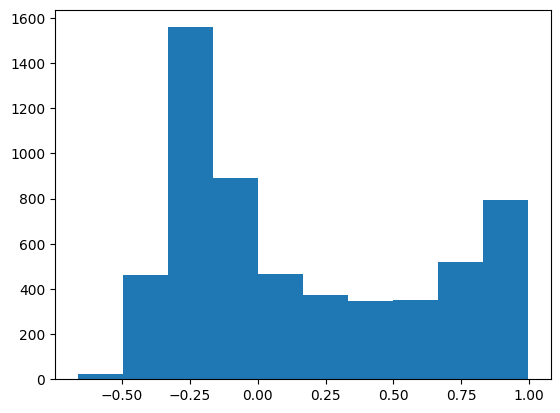

In [72]:
plt.hist(pearson_vals)

In [23]:
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from scipy.stats import shapiro

In [28]:
## Much faster code

np.random.seed(33)
nIterations = 1000

bcPearsonShuffled = np.zeros(nIterations)
bcSpearmanShuffled = np.zeros(nIterations)
bcManhattanShuffled = np.zeros(nIterations)
bcEuclidShuffled = np.zeros(nIterations)

nSamples = useDF.shape[0]

# Precompute combinations count
nCombinations = nSamples * (nSamples - 1) // 2


start = time.time()

for k in range(nIterations):
    shuffleDF = useDF.copy()
    
    # Shuffle columns independently
    for col in unnormalized_sorted_columns:
        shuffleDF[col] = np.random.permutation(useDF[col].values)
    
    # Normalize the specified columns row-wise
    shuffleDF[sorted_columns] = shuffleDF[unnormalized_sorted_columns].div(
        shuffleDF[unnormalized_sorted_columns].sum(axis=1), axis=0)
    
    # Convert to numpy array for speed
    arr = shuffleDF[sorted_columns].values
    
    # Pearson correlation matrix between rows (transpose so rows are features)
    # Since np.corrcoef works on rows as variables, we transpose arr
    corr_matrix_pearson = np.corrcoef(arr)
    
    # Extract upper triangle (pairs)
    pearson_vals = corr_matrix_pearson[np.triu_indices(nSamples, k=1)]
    
    # Spearman correlation: Compute rank-transformed data, then pearson corrcoef
    rank_arr = np.apply_along_axis(lambda x: pd.Series(x).rank().values, axis=1, arr=arr)
    corr_matrix_spearman = np.corrcoef(rank_arr)
    spearman_vals = corr_matrix_spearman[np.triu_indices(nSamples, k=1)]
    
    # Manhattan distance between rows (pdist with 'cityblock')
    manhattan_vals = pdist(arr, metric='cityblock')
    
    # Euclidean on sqrt transformed data
    sqrt_arr = np.sqrt(arr)
    euclid_vals = pdist(sqrt_arr, metric='euclidean')
    
    # Calculate bimodality coefficients
    bcPearsonShuffled[k] = bimodality_coefficient(pearson_vals)
    bcSpearmanShuffled[k] = bimodality_coefficient(spearman_vals)
    bcManhattanShuffled[k] = bimodality_coefficient(manhattan_vals)
    bcEuclidShuffled[k] = bimodality_coefficient(euclid_vals)

end = time.time()
print(f"Elapsed time: {end - start:.4f} seconds")

Elapsed time: 22.0542 seconds


In [78]:
shuffleDF[unnormalized_sorted_columns].div(
        shuffleDF[unnormalized_sorted_columns].sum(axis=1), axis=0)

,unnorm_OLF,unnorm_Isocortex,unnorm_HPF,unnorm_CTXsp,unnorm_CNU,unnorm_TH,unnorm_HY,unnorm_MB,unnorm_CB,unnorm_P,unnorm_MY,unnorm_Other
0,0.000000,0.000000,0.438118,0.058909,0.021170,0.000000,0.069183,0.075667,0.023764,0.025854,0.271880,0.015455
1,0.110212,0.437664,0.053219,0.012345,0.084550,0.002952,0.000000,0.024934,0.167988,0.065519,0.009519,0.031100
2,0.057115,0.000000,0.155943,0.162295,0.024346,0.000000,0.115724,0.048001,0.090744,0.015859,0.116312,0.213661
3,0.399770,0.000000,0.000103,0.026583,0.055629,0.004556,0.012631,0.167172,0.058912,0.081345,0.131506,0.061793
4,0.157290,0.283687,0.011232,0.042828,0.014311,0.041381,0.033627,0.039543,0.026461,0.159316,0.001463,0.188861
...,...,...,...,...,...,...,...,...,...,...,...,...
103,0.479509,0.228816,0.126324,0.005208,0.000000,0.016299,0.049651,0.009325,0.003385,0.049738,0.004278,0.027466
104,0.369586,0.000000,0.561633,0.006191,0.003975,0.000000,0.000000,0.008955,0.000000,0.017898,0.015221,0.016541
105,0.000000,0.001705,0.664734,0.000000,0.000000,0.000056,0.043010,0.097529,0.000000,0.039342,0.014618,0.139006
106,0.070192,0.000000,0.204176,0.000000,0.114819,0.193622,0.087163,0.046814,0.000000,0.016763,0.179674,0.086776


<Axes: >

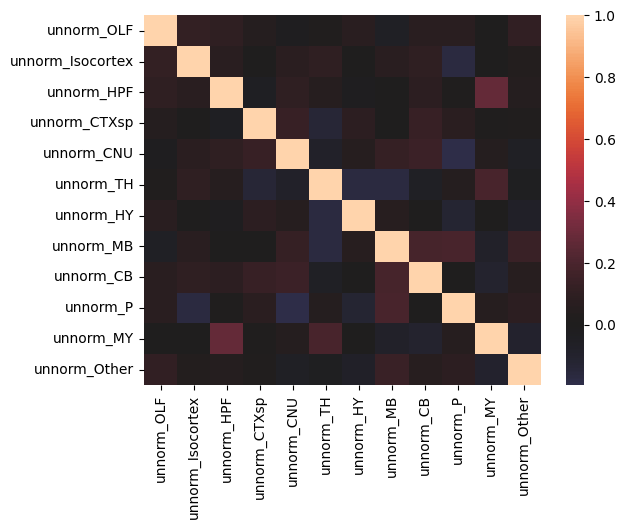

In [92]:
sns.heatmap(shuffleDF[unnormalized_sorted_columns].corr("spearman"), center = 0)

<Axes: >

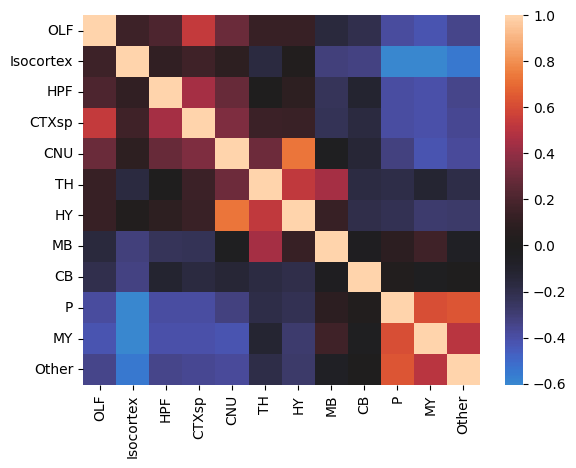

In [87]:
sns.heatmap(useDF[sorted_columns].corr(), center = 0)

In [49]:
bimodality_coefficient(corrDF["manhattanNorm"])

0.6055393992389784

In [35]:
np.mean(np.abs(bcManhattanShuffled) >= np.abs(bimodality_coefficient(corrDF["manhattanNorm"])))

0.001

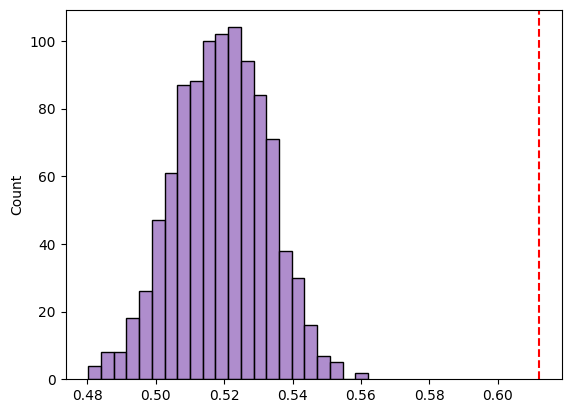

In [36]:
sns.histplot(bcEuclidShuffled, bins = 0, color = "tab:purple")
plt.axvline(bimodality_coefficient(corrDF["euclideanNorm"]),color='red', linestyle='--', label='Observed statistic')
# plt.xlim([-0.05, 2.05])
# plt.ylim([0,575])
# plt.title("Pairwise L2 Norm");
# plt.savefig("../results/lc coarse projection pairwise L2 norm.png",dpi=300, bbox_inches='tight')

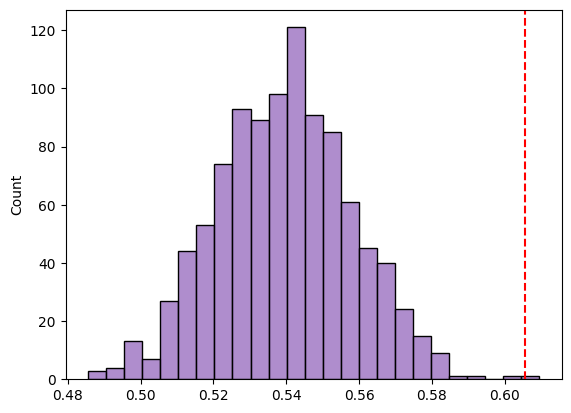

In [51]:
sns.histplot(bcManhattanShuffled, color = "tab:purple")
plt.axvline(bimodality_coefficient(corrDF["manhattanNorm"]),color='red', linestyle='--', label='Observed statistic')
# plt.xlim([-0.05, 2.05])
# plt.ylim([0,575])
# plt.title("Pairwise L2 Norm");
# plt.savefig("../results/lc coarse projection pairwise L2 norm.png",dpi=300, bbox_inches='tight')

In [ ]:
# Initialize output
data = np.zeros((nCombinations,10), dtype=np.float64)
# Loop through every pair of neurons
for indx, (i,j) in enumerate(combinations(useDF.index,2)):
    # Compute relevant metrics
    distDV = np.abs(useDF.loc[i,"somaDV"] - useDF.loc[j,"somaDV"])
    dist3D = np.linalg.norm(useDF.loc[i,["somaAP","somaDV","somaML"]].values - useDF.loc[j,["somaAP","somaDV","somaML"]].values)
    unnormPearson = useDF.loc[[i,j],unnormalized_sorted_columns].T.corr(method="pearson").iloc[0,1]
    unnormSpearman = useDF.loc[[i,j],unnormalized_sorted_columns].T.corr(method="spearman").iloc[0,1]
    corrPearson = useDF.loc[[i,j],sorted_columns].T.corr(method="pearson").iloc[0,1]
    corrSpearman = useDF.loc[[i,j],sorted_columns].T.corr(method="spearman").iloc[0,1]
    manhattanNorm = np.abs(useDF.loc[i,sorted_columns] - useDF.loc[j,sorted_columns]).sum()
    euclideanNorm = (((useDF.loc[i,sorted_columns]**.5) - (useDF.loc[j,sorted_columns]**.5)) ** 2).sum() ** .5
    data[indx] = [i, j, distDV, dist3D, unnormPearson, unnormSpearman, corrPearson, corrSpearman, manhattanNorm, euclideanNorm]

corrDF = pd.DataFrame(data,columns = ["i","j","distDV","dist3D","unnormPearson","unnormSpearman","corrPearson","corrSpearman","manhattanNorm", "euclideanNorm"])
corrDF[["i","j"]] = corrDF[["i","j"]].astype(int)

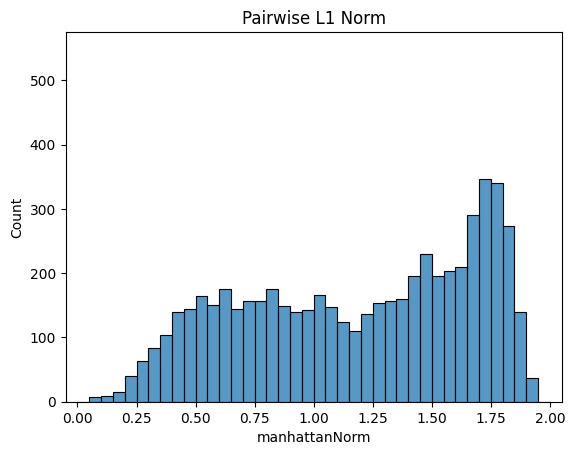

In [204]:
sns.histplot(corrDF["manhattanNorm"],bins = np.linspace(0,2,41), color = "tab:blue")
plt.xlim([-0.05, 2.05])
plt.ylim([0,575])
plt.title("Pairwise L1 Norm");
plt.savefig("../results/lc coarse projection pairwise L1 norm.png",dpi=300, bbox_inches='tight')

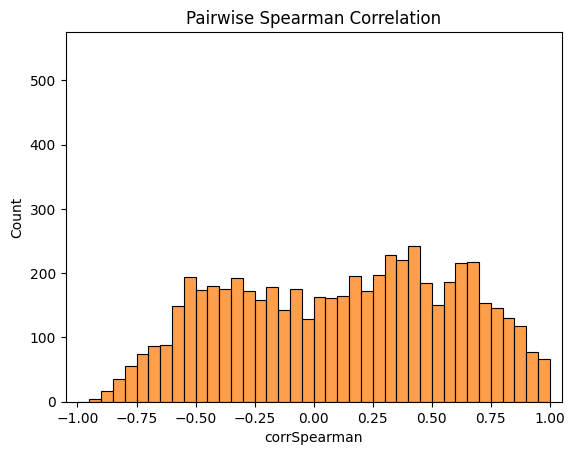

In [203]:
sns.histplot(corrDF["corrSpearman"],bins = np.linspace(-1,1,41),color = "tab:orange")
plt.xlim([-1.05, 1.05])
plt.ylim([0,575])
plt.title("Pairwise Spearman Correlation");
plt.savefig("../results/lc coarse projection pairwise spearman correlation.png",dpi=300, bbox_inches='tight')

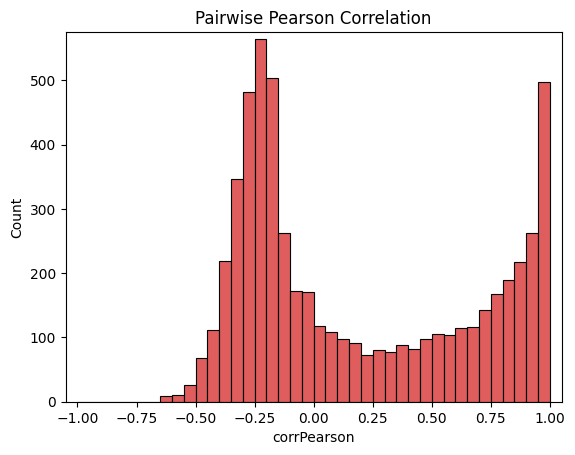

In [202]:
sns.histplot(corrDF["corrPearson"],bins = np.linspace(-1,1,41), color = 'tab:red')
plt.xlim([-1.05, 1.05])
plt.ylim([0,575])
plt.title("Pairwise Pearson Correlation");
plt.savefig("../results/lc coarse projection pairwise pearson correlation.png",dpi=300, bbox_inches='tight')

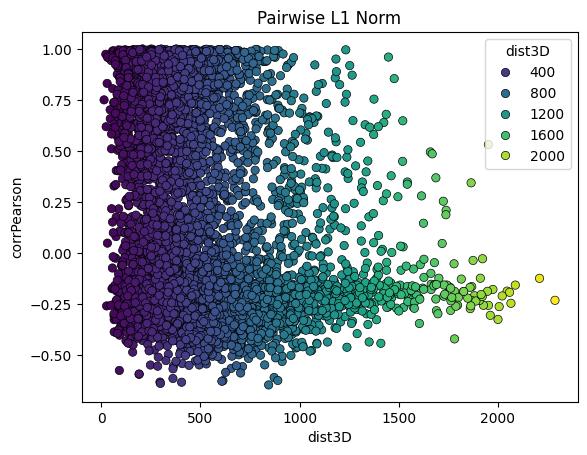

In [246]:
# sns.scatter(data = corrDFcorrDF["manhattanNorm"],bins = np.linspace(0,2,41), color = "tab:blue")
sns.scatterplot(data = corrDF, x= "dist3D", y = "corrPearson", hue = "dist3D", edgecolor = 'k', palette = "viridis")
# plt.plot(corrDF["manhattanNorm"], corrDF["dist3D"], '.', color = 'darkgray', markeredgecolor = 'k')
# plt.xlim([-0.05, 2.05])
# plt.ylim([0,575])
plt.title("Pairwise L1 Norm");
# plt.savefig("../results/lc coarse projection pairwise L1 norm.png",dpi=300, bbox_inches='tight')

<Axes: xlabel='distDV', ylabel='dist3D'>

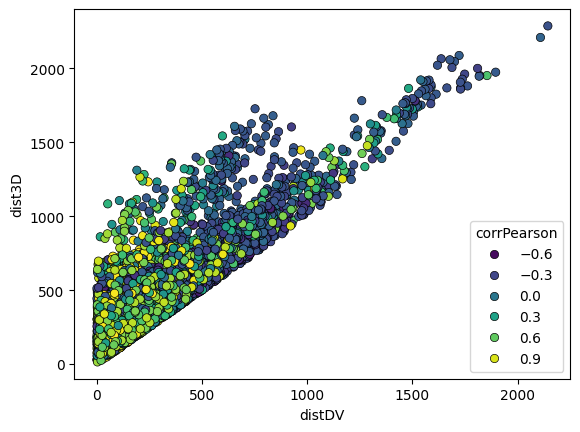

In [249]:
sns.scatterplot(data = corrDF, x= "distDV", y = "dist3D", hue = "corrPearson", edgecolor = 'k', palette = "viridis")

In [84]:
corrDF.sort_values("corr",ascending=False).head(10)

,i,j,distDV,dist3D,corr
3329,37,74,201.3565,208.261796,0.999657
4366,54,74,146.3258,378.461398,0.999556
3309,37,54,55.0307,302.597859,0.999358
1604,16,29,118.1490,253.027016,0.999237
2193,22,93,513.9537,530.607854,0.998174
1027,10,13,7.0975,632.650392,0.997542
1364,13,65,372.5768,779.050910,0.997355
1353,13,54,259.4732,600.593172,0.997088
220,2,10,166.6037,259.612794,0.997005
2402,25,53,113.0697,163.016522,0.996795


<Axes: >

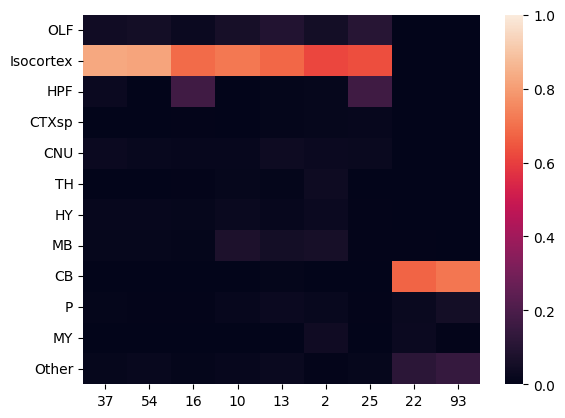

In [93]:
sns.heatmap(useDF.loc[[37,54,16,10,13,2,25, 22, 93],sorted_columns].T, vmax = 1, vmin = 0)

#### Add clustering

In [38]:
from sklearn.cluster import KMeans

Text(0, 0.5, 'WCSS')

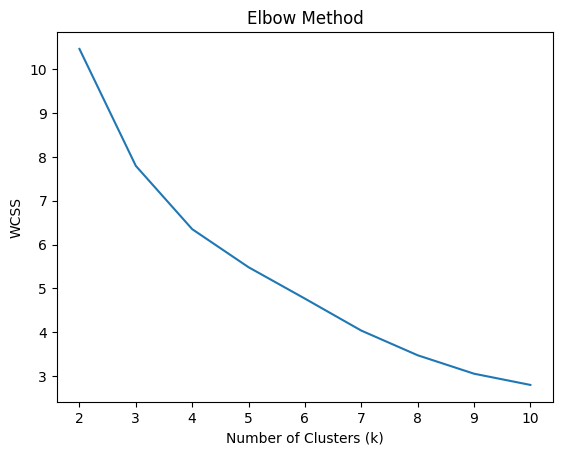

In [39]:
# Assuming 'X' is your dataset
wcss = []
# max_clusters = 15
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=0, n_init=10)
    kmeans.fit(useDF.loc[:,sorted_columns])
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')

In [108]:
# Define the model (e.g., 2 clusters)
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(useDF.loc[:,sorted_columns])

# Add cluster labels to the original DataFrame
# df['Cluster'] = kmeans.labels_

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=2, random_state=0)

In [16]:
useDF.loc[:,sorted_columns]

,OLF,Isocortex,HPF,CTXsp,CNU,TH,HY,MB,CB,P,MY,Other
0,0.056417,0.126479,0.481565,0.029729,0.029880,0.061198,0.024325,0.052600,0.000121,0.009790,0.025641,0.030485
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.122989,0.555582,0.039680,0.025943,0.000000
2,0.054157,0.616744,0.014504,0.015004,0.029180,0.037415,0.030135,0.058913,0.000000,0.022086,0.039577,0.005936
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.128645,0.000000,0.047866,0.166421,0.590163
4,0.112453,0.451889,0.206806,0.028629,0.016647,0.052443,0.007660,0.023519,0.002613,0.007241,0.000000,0.026179
...,...,...,...,...,...,...,...,...,...,...,...,...
103,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.156169,0.203401,0.634154
104,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.225847,0.219988,0.162349,0.307591
105,0.000000,0.000000,0.000000,0.000000,0.000000,0.000133,0.000000,0.231097,0.000000,0.206456,0.272502,0.269424
106,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.013323,0.000000,0.216441,0.241026,0.524626


In [41]:
from scipy.stats import rankdata
from scipy import stats

In [42]:
# Store results
all_corrs = {}
all_dists = {}
clusterDF = useDF.loc[:,sorted_columns + ["somaAP","somaDV","somaML"]].copy()
clusterDF["cluster_label"] = kmeans.labels_
for cluster in clusterDF["cluster_label"].unique():
    sub_df = clusterDF[clusterDF['cluster_label'] == cluster]

    # Extract features and positions
    features = sub_df[sorted_columns].values
    positions = sub_df[["somaAP","somaDV","somaML"]].values
    # positions = sub_df[["somaDV"]].values

    # Rank-transform each feature vector (row-wise ranking)
    ranked_features = np.apply_along_axis(rankdata, 1, features)

    # Now compute 1 - correlation distance (which is now 1 - Spearman correlation)
    corr = 1 - pdist(ranked_features, metric='correlation')
    dist = pdist(positions, metric='euclidean')

    all_corrs[cluster] = corr
    all_dists[cluster] = dist

In [109]:
# Store results
all_corrs = {}
all_dists = {}
clusterDF = useDF.loc[:,sorted_columns + ["somaAP","somaDV","somaML"]].copy()
clusterDF["cluster_label"] = kmeans.labels_
for cluster in clusterDF["cluster_label"].unique():
    sub_df = clusterDF[clusterDF['cluster_label'] == cluster]

    # Extract features and positions
    features = sub_df[sorted_columns].values
    positions = sub_df[["somaAP","somaDV","somaML"]].values
    # positions = sub_df[["somaDV"]].values

    # Now compute 1 - correlation distance (which is now 1 - Spearman correlation)
    corr = 1 - pdist(features, metric='correlation')
    dist = pdist(positions, metric='euclidean')

    all_corrs[cluster] = corr
    all_dists[cluster] = dist

In [43]:
all_corrs

{0: array([0.3986014 , 0.8951049 , 0.33566434, ..., 0.6013986 , 0.17482517,
        0.0979021 ]),
 1: array([ 0.41336634, -0.12897424,  0.74694096, ...,  0.91859819,
         0.73696104,  0.87375617])}

<Axes: >

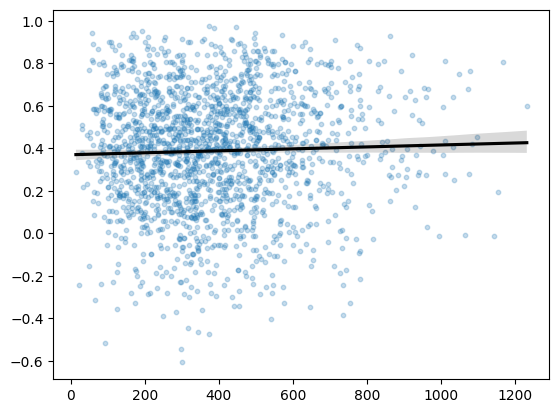

In [44]:
cluster_label = 0
cluster_color_dict = {0:"tab:blue",1:"tab:orange"}
sns.regplot(x = all_dists[cluster_label],y = all_corrs[cluster_label], color = cluster_color_dict[cluster_label], scatter_kws={'s' : 10, 'alpha': 0.25}, line_kws = {"color":'k'})

<Axes: >

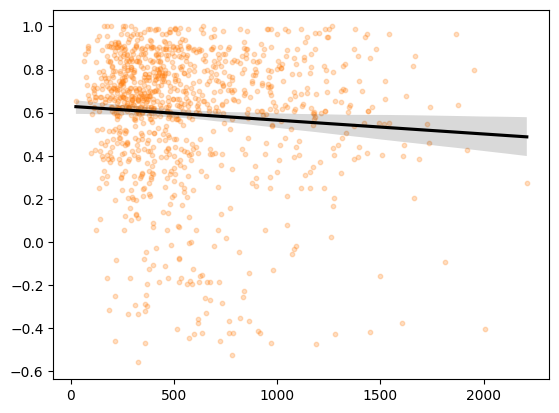

In [70]:
cluster_label = 1
cluster_color_dict = {0:"tab:blue",1:"tab:orange"}
sns.regplot(x = all_dists[cluster_label],y = all_corrs[cluster_label], color = cluster_color_dict[cluster_label], scatter_kws={'s' : 10, 'alpha': 0.25}, line_kws = {"color":'k'})

<Axes: >

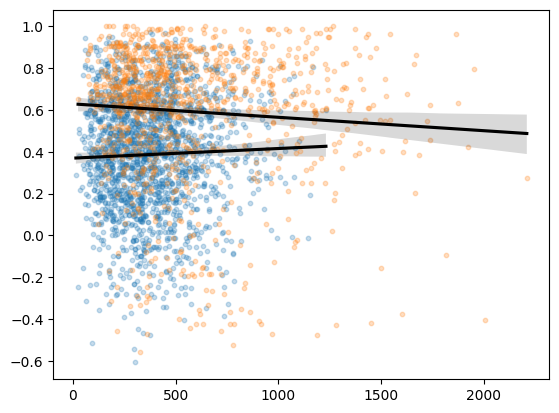

In [51]:
cluster_color_dict = {0:"tab:blue",1:"tab:orange"}
cluster_label = 0
sns.regplot(x = all_dists[cluster_label],y = all_corrs[cluster_label], color = cluster_color_dict[cluster_label], scatter_kws={'s' : 10, 'alpha': 0.25}, line_kws = {"color":'k'})
cluster_label = 1
sns.regplot(x = all_dists[cluster_label],y = all_corrs[cluster_label], color = cluster_color_dict[cluster_label], scatter_kws={'s' : 10, 'alpha': 0.25}, line_kws = {"color":'k'})

<Axes: >

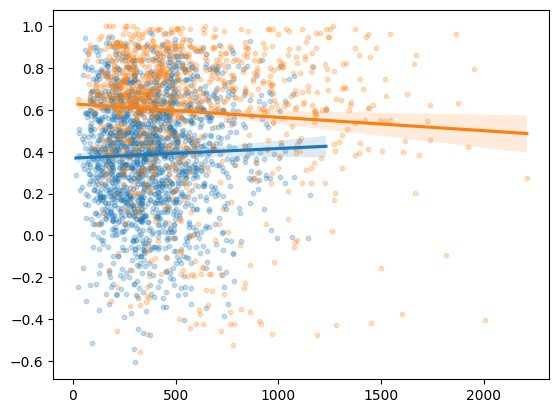

In [55]:
cluster_color_dict = {0:"tab:blue",1:"tab:orange"}
cluster_label = 0
sns.regplot(x = all_dists[cluster_label],y = all_corrs[cluster_label], color = cluster_color_dict[cluster_label], scatter_kws={'s' : 10, 'alpha': 0.25}, line_kws = {"color":cluster_color_dict[cluster_label]})
cluster_label = 1
sns.regplot(x = all_dists[cluster_label],y = all_corrs[cluster_label], color = cluster_color_dict[cluster_label], scatter_kws={'s' : 10, 'alpha': 0.25}, line_kws = {"color":cluster_color_dict[cluster_label]})

(-1.05, 1.05)

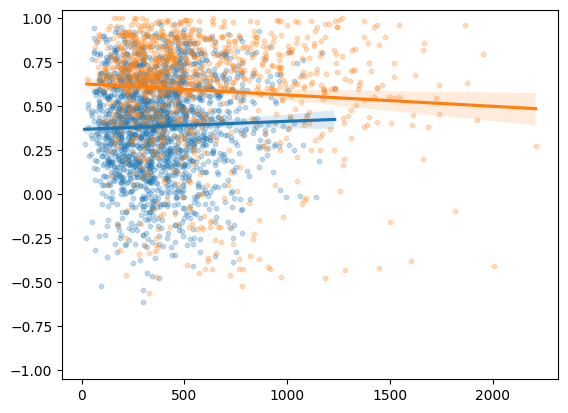

In [60]:
cluster_color_dict = {0:"tab:blue",1:"tab:orange"}
cluster_label = 0
sns.regplot(x = all_dists[cluster_label],y = all_corrs[cluster_label], color = cluster_color_dict[cluster_label], scatter_kws={'s' : 10, 'alpha': 0.25}, line_kws = {"color":cluster_color_dict[cluster_label]})
cluster_label = 1
sns.regplot(x = all_dists[cluster_label],y = all_corrs[cluster_label], color = cluster_color_dict[cluster_label], scatter_kws={'s' : 10, 'alpha': 0.25}, line_kws = {"color":cluster_color_dict[cluster_label]})
plt.ylim([-1.05, 1.05])

(-1.05, 1.05)

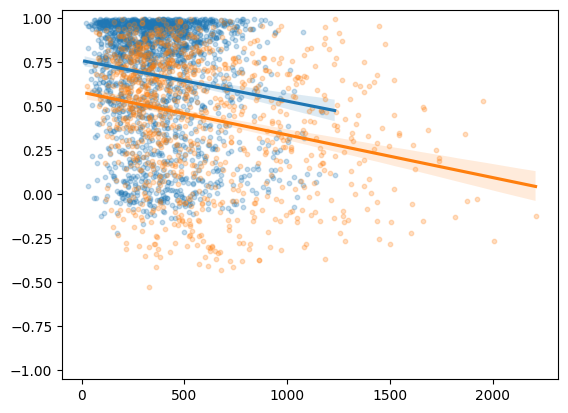

In [110]:
cluster_color_dict = {0:"tab:blue",1:"tab:orange"}
cluster_label = 0
sns.regplot(x = all_dists[cluster_label],y = all_corrs[cluster_label], color = cluster_color_dict[cluster_label], scatter_kws={'s' : 10, 'alpha': 0.25}, line_kws = {"color":cluster_color_dict[cluster_label]})
cluster_label = 1
sns.regplot(x = all_dists[cluster_label],y = all_corrs[cluster_label], color = cluster_color_dict[cluster_label], scatter_kws={'s' : 10, 'alpha': 0.25}, line_kws = {"color":cluster_color_dict[cluster_label]})
plt.ylim([-1.05, 1.05])

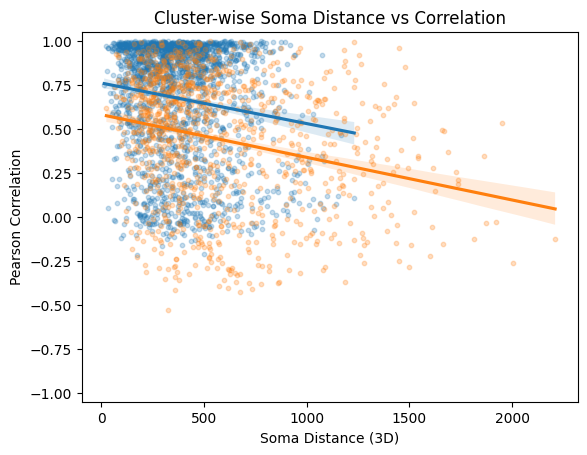

In [115]:
cluster_color_dict = {0:"tab:blue",1:"tab:orange"}
cluster_label = 0
sns.regplot(x = all_dists[cluster_label],y = all_corrs[cluster_label], color = cluster_color_dict[cluster_label], scatter_kws={'s' : 10, 'alpha': 0.25}, line_kws = {"color":cluster_color_dict[cluster_label]})
cluster_label = 1
sns.regplot(x = all_dists[cluster_label],y = all_corrs[cluster_label], color = cluster_color_dict[cluster_label], scatter_kws={'s' : 10, 'alpha': 0.25}, line_kws = {"color":cluster_color_dict[cluster_label]})
plt.ylim([-1.05, 1.05])
plt.xlabel("Soma Distance (3D)")
plt.ylabel("Pearson Correlation")
plt.title("Cluster-wise Soma Distance vs Correlation")
plt.savefig("../results/lc coarse projection position vs pairwise pearson clustered.png",dpi=300, bbox_inches='tight')

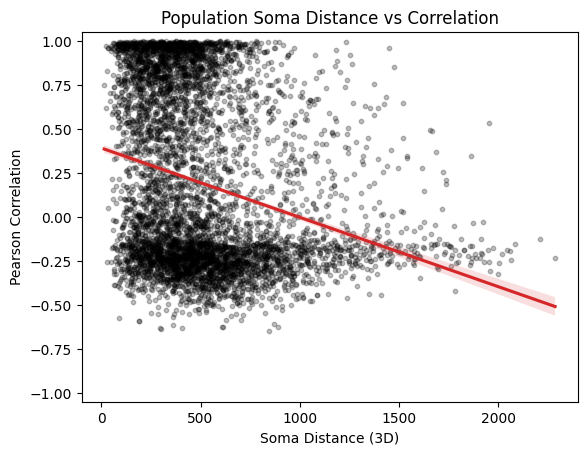

In [114]:
sns.regplot(corrDF,x = "dist3D",y = "corrPearson", color = 'k', scatter_kws={'s' : 10, 'alpha': 0.25}, line_kws = {"color":'tab:red'})
plt.ylim([-1.05, 1.05])
plt.xlabel("Soma Distance (3D)")
plt.ylabel("Pearson Correlation")
plt.title("Population Soma Distance vs Correlation")
plt.savefig("../results/lc coarse projection position vs pairwise pearson.png",dpi=300, bbox_inches='tight')

(-1.05, 1.05)

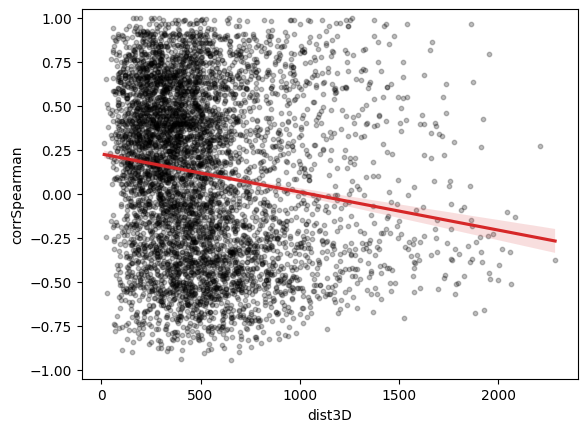

In [71]:
sns.regplot(corrDF,x = "dist3D",y = "corrSpearman", color = 'k', scatter_kws={'s' : 10, 'alpha': 0.25}, line_kws = {"color":'tab:red'})
plt.ylim([-1.05, 1.05])

Slope: -0.000
Intercept: 0.629
R-squared: 0.006
P-value (for slope): 0.017
Standard Error of slope: 0.000


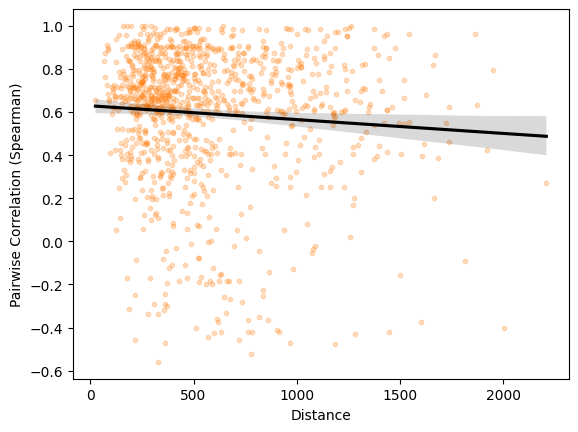

In [49]:
cluster_label = 1
cluster_color_dict = {0:"tab:blue",1:"tab:orange",2:"tab:green"}
sns.regplot(x = all_dists[cluster_label],y = all_corrs[cluster_label], color = cluster_color_dict[cluster_label], scatter_kws={'s' : 10, 'alpha': 0.25}, line_kws = {"color":'k'})
plt.xlabel("Distance")
plt.ylabel("Pairwise Correlation (Spearman)")
slope, intercept, r_value, p_value, std_err = stats.linregress(all_dists[cluster_label], all_corrs[cluster_label])

print(f"Slope: {slope:.3f}")
print(f"Intercept: {intercept:.3f}")
print(f"R-squared: {r_value**2:.3f}")
print(f"P-value (for slope): {p_value:.3f}")
print(f"Standard Error of slope: {std_err:.3f}")

In [49]:
distDV = np.abs(useDF.loc[i,"somaDV"] - useDF.loc[j,"somaDV"])
dist3D = np.linalg.norm(useDF.loc[i,["somaAP","somaDV","somaML"]].values - useDF.loc[j,["somaAP","somaDV","somaML"]].values)

In [42]:
def get_within_cluster_spearman(df, df_pos labels):
    cluster_corrs = {}
    cluster_distDV = {}
    cluster_dist3D = {}
    for cluster in np.unique(labels):
        sub_df = df[labels == cluster]
        if len(sub_df) < 2:
            cluster_corrs[cluster] = []  # No pairs to correlate
            continue
        # Transpose to compute sample-wise correlation
        corr_matrix = sub_df.T.corr(method="spearman")
        # Extract upper triangle (excluding diagonal)
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        cluster_corrs[cluster] = upper_tri.stack().values
    return cluster_corrs

In [43]:
a = get_within_cluster_spearman(useDF.loc[:,sorted_columns], useDF[:,["somaAP","somaDV","somaML"]], kmeans.labels_)

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   2.,   2.,
          2.,   5.,   9.,  15.,  18.,  22.,  20.,  41.,  37.,  49.,  69.,
         65., 111.,  90., 108., 136., 135., 147., 129., 105., 119., 106.,
        104.,  69.,  61.,  54.,  34.,  22.,   4.]),
 array([-1.  , -0.95, -0.9 , -0.85, -0.8 , -0.75, -0.7 , -0.65, -0.6 ,
        -0.55, -0.5 , -0.45, -0.4 , -0.35, -0.3 , -0.25, -0.2 , -0.15,
        -0.1 , -0.05,  0.  ,  0.05,  0.1 ,  0.15,  0.2 ,  0.25,  0.3 ,
         0.35,  0.4 ,  0.45,  0.5 ,  0.55,  0.6 ,  0.65,  0.7 ,  0.75,
         0.8 ,  0.85,  0.9 ,  0.95,  1.  ]),
 <BarContainer object of 40 artists>)

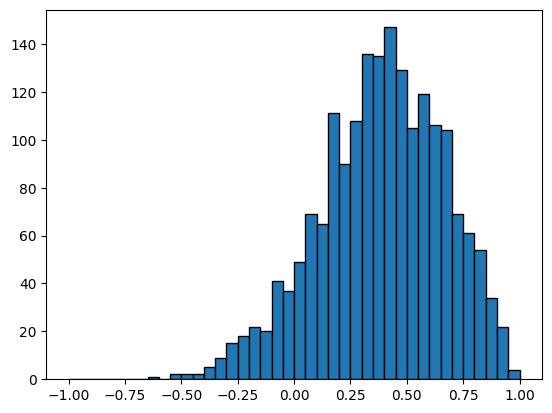

In [46]:
plt.hist(a[0], bins = np.linspace(-1,1,41), edgecolor = 'k')

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   1.,   5.,
         11.,   6.,   5.,   7.,   3.,  17.,   6.,   6.,   8.,   3.,  11.,
         10.,   8.,  18.,  22.,  28.,  30.,  50.,  34.,  30.,  53., 104.,
        110.,  85.,  85.,  77.,  84.,  55.,  62.]),
 array([-1.  , -0.95, -0.9 , -0.85, -0.8 , -0.75, -0.7 , -0.65, -0.6 ,
        -0.55, -0.5 , -0.45, -0.4 , -0.35, -0.3 , -0.25, -0.2 , -0.15,
        -0.1 , -0.05,  0.  ,  0.05,  0.1 ,  0.15,  0.2 ,  0.25,  0.3 ,
         0.35,  0.4 ,  0.45,  0.5 ,  0.55,  0.6 ,  0.65,  0.7 ,  0.75,
         0.8 ,  0.85,  0.9 ,  0.95,  1.  ]),
 <BarContainer object of 40 artists>)

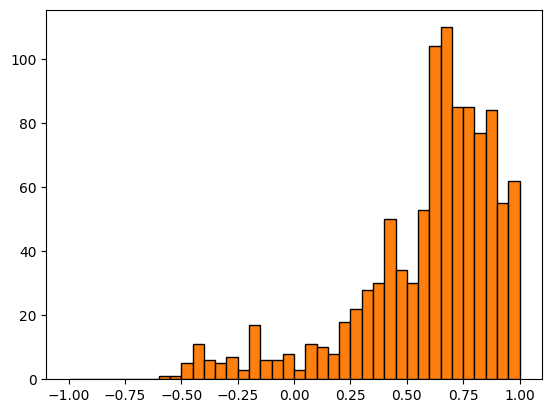

In [47]:
plt.hist(a[1], bins = np.linspace(-1,1,41), edgecolor = 'k', color = 'tab:orange')

In [ ]:
def get_between_cluster_spearman(df, labels):
    corrs = []
    clusters = labels.unique()
    features = df.to_numpy()

    # Rank across all samples (global ranking per feature)
    ranked = np.apply_along_axis(rankdata, axis=0, arr=features)

    for c1, c2 in combinations(clusters, 2):
        X1 = ranked[labels == c1]
        X2 = ranked[labels == c2]

        # Compute dot product of standardized ranks (i.e., Pearson of ranks)
        X1_std = (X1 - X1.mean(axis=1, keepdims=True)) / X1.std(axis=1, keepdims=True)
        X2_std = (X2 - X2.mean(axis=1, keepdims=True)) / X2.std(axis=1, keepdims=True)

        corr_matrix = np.dot(X1_std, X2_std.T) / X1.shape[1]  # same as Pearson
        corrs.extend(corr_matrix.ravel())
    return corrs